# 3D Wireframe Visualization with Color Zones

This notebook creates a 3D wireframe plot with:
- Parallel cosine curves as the surface data
- Different colors for lines in different directions
- Color change at 60% through the z-axis (horizontal plane division)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Enable interactive mode for matplotlib
%matplotlib widget

In [10]:
# Generate data for parallel cosine curves
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Create more diverse cosine curves - varying frequencies, phases, and amplitudes
Z = (
    np.cos(2 * np.pi * X) * (1 + 0.3 * Y)  # amplitude varies with Y
    + 0.6 * np.cos(1.5 * np.pi * Y + 0.5 * X)  # phase varies with X
    + 0.3 * np.sin(3 * X * Y)  # interaction term for complexity
)

print(f"Data shapes - X: {X.shape}, Y: {Y.shape}, Z: {Z.shape}")
print(f"Z range: {Z.min():.2f} to {Z.max():.2f}")

Data shapes - X: (100, 100), Y: (100, 100), Z: (100, 100)
Z range: -2.25 to 2.31


In [ ]:
from matplotlib.lines import Line2D
from numpy.typing import NDArray


def plot_data(
    X: NDArray[np.float64],
    Y: NDArray[np.float64],
    Z: NDArray[np.float64],
    z_split_pct: np.float64 = np.float64(0.6),
) -> tuple[plt.Figure, plt.Axes]:
    """
    Create a 3D wireframe plot with color zones split at a percentage of the z-axis.
    Color transitions occur exactly at the split plane via interpolation.

    Parameters:
        X, Y, Z: 2D arrays from meshgrid defining the surface
        z_split_pct: percentage (0-1) along z-axis where color changes (default 0.6)
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Calculate the z-axis split value
    z_min, z_max = Z.min(), Z.max()
    z_split_val = z_min + z_split_pct * (z_max - z_min)

    print(f"Z-axis range: {z_min:.2f} to {z_max:.2f}")
    print(f"{z_split_pct * 100:.0f}% split point: z = {z_split_val:.2f}")

    def plot_line_with_split(
        x_coords: NDArray[np.float64],
        y_coords: NDArray[np.float64],
        z_coords: NDArray[np.float64],
        color_below: str,
        color_above: str,
    ) -> None:
        """Plot a line with sharp color transition at z_split_val."""

        for i in range(len(x_coords) - 1):
            x0, x1 = x_coords[i], x_coords[i + 1]
            y0, y1 = y_coords[i], y_coords[i + 1]
            z0, z1 = z_coords[i], z_coords[i + 1]

            below_0 = z0 < z_split_val
            below_1 = z1 < z_split_val

            if below_0 == below_1:
                # Entire segment is on one side
                color = color_below if below_0 else color_above
                ax.plot(
                    [x0, x1], [y0, y1], [z0, z1], color=color, linewidth=1.5, alpha=0.8
                )
            else:
                # Segment crosses the threshold - interpolate the crossing point
                t = (z_split_val - z0) / (z1 - z0)
                x_mid = x0 + t * (x1 - x0)
                y_mid = y0 + t * (y1 - y0)
                z_mid = z_split_val

                # Draw both segments with appropriate colors
                if below_0:
                    ax.plot(
                        [x0, x_mid],
                        [y0, y_mid],
                        [z0, z_mid],
                        color=color_below,
                        linewidth=1.5,
                        alpha=0.8,
                    )
                    ax.plot(
                        [x_mid, x1],
                        [y_mid, y1],
                        [z_mid, z1],
                        color=color_above,
                        linewidth=1.5,
                        alpha=0.8,
                    )
                else:
                    ax.plot(
                        [x0, x_mid],
                        [y0, y_mid],
                        [z0, z_mid],
                        color=color_above,
                        linewidth=1.5,
                        alpha=0.8,
                    )
                    ax.plot(
                        [x_mid, x1],
                        [y_mid, y1],
                        [z_mid, z1],
                        color=color_below,
                        linewidth=1.5,
                        alpha=0.8,
                    )

    # Plot X-direction lines (rows)
    for i in range(X.shape[0]):
        plot_line_with_split(X[i, :], Y[i, :], Z[i, :], "b", "r")

    # Plot Y-direction lines (columns)
    for j in range(X.shape[1]):
        plot_line_with_split(X[:, j], Y[:, j], Z[:, j], "g", "orange")

    # Add labels and title
    ax.set_xlabel("X Axis", fontsize=12)
    ax.set_ylabel("Y Axis", fontsize=12)
    ax.set_zlabel("Z Axis", fontsize=12)
    ax.set_title(
        f"3D Wireframe with Directional Colors\nColor split at {z_split_pct * 100:.0f}% Z-axis",
        fontsize=14,
        pad=20,
    )

    # Add a horizontal plane indicator at the split point
    x_range = [X.min(), X.max()]
    y_range = [Y.min(), Y.max()]
    plane_x = np.array([[x_range[0], x_range[0]], [x_range[1], x_range[1]]])
    plane_y = np.array([[y_range[0], y_range[1]], [y_range[0], y_range[1]]])
    plane_z = np.array([[z_split_val, z_split_val], [z_split_val, z_split_val]])
    ax.plot_surface(plane_x, plane_y, plane_z, alpha=0.15, color="gray")

    # Add legend
    legend_elements = [
        Line2D([0], [0], color="b", lw=2, label="X-direction (below split)"),
        Line2D([0], [0], color="r", lw=2, label="X-direction (above split)"),
        Line2D([0], [0], color="g", lw=2, label="Y-direction (below split)"),
        Line2D([0], [0], color="orange", lw=2, label="Y-direction (above split)"),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=2,
            alpha=0.3,
            label=f"{z_split_pct * 100:.0f}% Z split plane",
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

    # Set viewing angle
    ax.view_init(elev=25, azim=45)

    plt.tight_layout()
    plt.show()

    return fig, ax


print("plot_data function defined.")

Z-axis range: -2.25 to 2.31
60% split point: z = 0.49


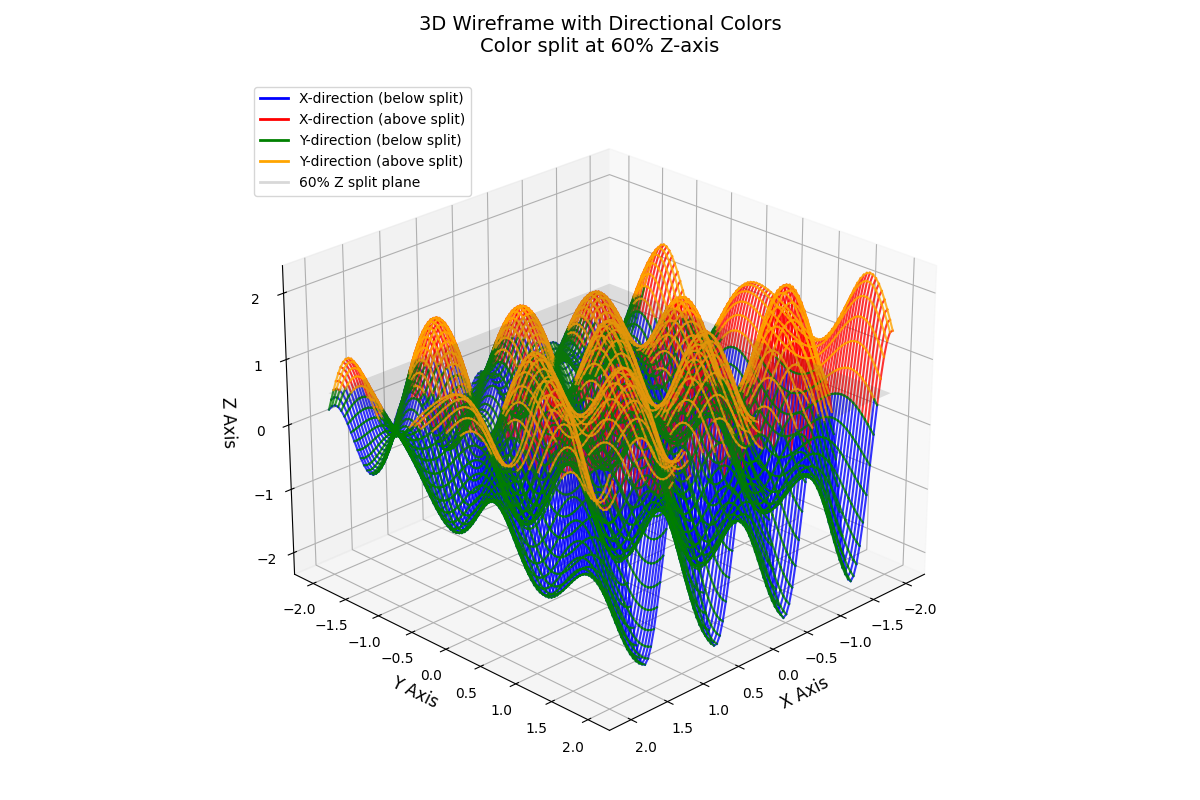

Plot displayed.


In [12]:
# Call the plotting function with our data
fig, ax = plot_data(X, Y, Z)

print("Plot displayed.")